In [1]:
# TensorFlow
import tensorflow as tf
print("TensorFlow Version:", tf.version)

TensorFlow Version: <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

from tensorflow.keras.optimizers import Adam

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
!pip -q install kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print(path)

Using Colab cache for faster access to the 'tomatoleaf' dataset.
/kaggle/input/tomatoleaf


In [5]:
train_path = os.path.join(path, "tomato", "train")
val_path = os.path.join(path, "tomato", "val")

print(train_path)
print(val_path)

/kaggle/input/tomatoleaf/tomato/train
/kaggle/input/tomatoleaf/tomato/val


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 10000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.


In [8]:
print("Training Images :", train_generator.samples)
print("Validation Images :", val_generator.samples)

print("Classes:")
print(train_generator.class_indices)

Training Images : 10000
Validation Images : 1000
Classes:
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 222s 610ms/step - accuracy: 0.7072 - loss: 0.8528 - val_accuracy: 0.8470 - val_loss: 0.4657
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 406ms/step - accuracy: 0.8319 - loss: 0.4888 - val_accuracy: 0.8980 - val_loss: 0.3357
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 414ms/step - accuracy: 0.8539 - loss: 0.4210 - val_accuracy: 0.8650 - val_loss: 0.3628
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 411ms/step - accuracy: 0.8712 - loss: 0.3718 - val_accuracy: 0.9150 - val_loss: 0.2694
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 436ms/step - accuracy: 0.8753 - loss: 0.3552 - val_accuracy: 0.9180 - val_loss: 0.2614
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 421ms/step - accuracy: 0.8904 - loss: 0.3250 - val_accuracy: 0.9180 - val_loss: 0.2262
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 412ms/step - accuracy: 0.8925 - loss: 0.3162 - val_accuracy: 0.9190 - val_loss: 0.2368
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 407ms/step - accuracy: 0.8992 -

In [13]:
model.save("TomatoVisionAI_EfficientNetB0.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Tahmin : Tomato___Leaf_Mold
Güven : %56.25


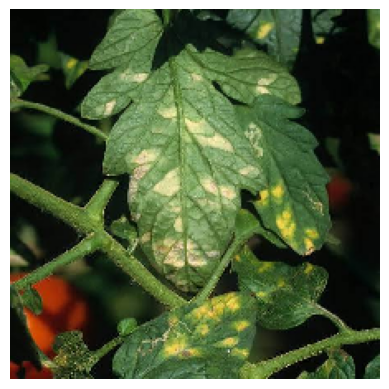

In [20]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/images (4).jpg"   # Buraya test fotoğrafını koy

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

prediction = model.predict(x)

class_names = list(train_generator.class_indices.keys())

predicted = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Tahmin :", predicted)
print(f"Güven : %{confidence*100:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Tahmin : Tomato___Early_blight
Güven : %92.83


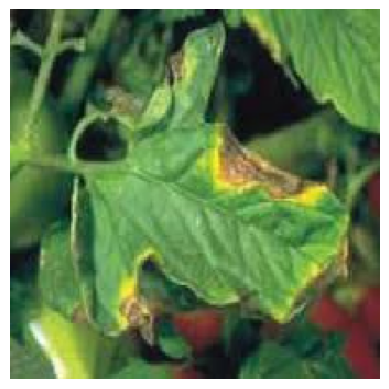

In [25]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/test_leaf . jpg"   # Buraya test fotoğrafını koy

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis("off")

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

prediction = model.predict(x)

class_names = list(train_generator.class_indices.keys())

predicted = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print("Tahmin :", predicted)
print(f"Güven : %{confidence*100:.2f}")

In [26]:
disease_info = {
    "Tomato_Bacterial_spot": {
        "description": "Bacterial Spot is caused by bacteria and spreads rapidly in warm, humid conditions.",
        "solution": "Remove infected leaves, avoid overhead irrigation, and use copper-based bactericides if necessary."
    },

    "Tomato_Early_blight": {
        "description": "Early Blight is a fungal disease that causes dark spots on older leaves.",
        "solution": "Remove infected leaves, rotate crops, and apply a suitable fungicide."
    },

    "Tomato_Late_blight": {
        "description": "Late Blight spreads quickly and can destroy tomato plants in a short time.",
        "solution": "Remove infected plants immediately and apply recommended fungicides."
    },

    "Tomato_Leaf_Mold": {
        "description": "Leaf Mold develops in humid greenhouse conditions.",
        "solution": "Improve ventilation, reduce humidity, and remove infected leaves."
    },

    "Tomato_Septoria_leaf_spot": {
        "description": "Septoria Leaf Spot appears as many small dark spots on leaves.",
        "solution": "Remove infected leaves and avoid wetting the foliage."
    },

    "Tomato_Spider_mites": {
        "description": "Spider mites feed on leaves and cause yellow speckles.",
        "solution": "Increase humidity and use suitable miticides if needed."
    },

    "Tomato_Target_Spot": {
        "description": "Target Spot causes circular lesions that reduce yield.",
        "solution": "Remove infected leaves and improve air circulation."
    },

    "Tomato_Yellow_Leaf_Curl_Virus": {
        "description": "A viral disease transmitted mainly by whiteflies.",
        "solution": "Control whiteflies and remove infected plants."
    },

    "Tomato_Mosaic_Virus": {
        "description": "A viral disease that causes mosaic patterns on leaves.",
        "solution": "Use clean tools and remove infected plants."
    },

    "Tomato_Healthy": {
        "description": "The tomato leaf appears healthy.",
        "solution": "Continue normal irrigation, fertilization, and monitoring."
    }
}

In [29]:
corrected_predicted = predicted.replace('___', '_').replace('__', '_') # Adjust predicted string to match dictionary keys
info = disease_info[corrected_predicted]

print("📖 Disease Information")
print(info["description"])

print("🌱 Recommendation")
print(info["solution"])

📖 Disease Information
Early Blight is a fungal disease that causes dark spots on older leaves.
🌱 Recommendation
Remove infected leaves, rotate crops, and apply a suitable fungicide.


In [31]:
print(train_generator.class_indices)

{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,041,091 (19.23 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 661,014 (2.52 MB)

In [35]:
!pip install streamlit
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="TomatoVision AI", page_icon="🍅")

st.title("🍅 TomatoVision AI")
st.write("AI Powered Tomato Leaf Disease Detection")

model = tf.keras.models.load_model("TomatoVisionAI_EfficientNetB0.keras")

classes = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato_Target_Spot",
    "Tomato_Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_Tomato_mosaic_virus",
    "Tomato_healthy"
]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.1 MB/s eta 0:00:00


2026-07-13 19:27:37.486 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:27:37.487 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:27:37.779 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-13 19:27:37.780 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:27:37.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:27:37.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:27:37.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [36]:
import os
print(os.listdir())

['.config', 'TomatoVisionAI_EfficientNetB0.keras', 'test_leaf . jpg', 'images (4).jpg', 'best_model.keras', '.ipynb_checkpoints', 'sample_data']


In [37]:
%%writefile app.py
print("Merhaba TomatoVision AI")

Writing app.py


In [38]:
import os
print(os.listdir())

['.config', 'TomatoVisionAI_EfficientNetB0.keras', 'app.py', 'test_leaf . jpg', 'images (4).jpg', 'best_model.keras', '.ipynb_checkpoints', 'sample_data']


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-07-13 19:35:09.591 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.246.161:8501

